<h2 style="color:green" align="center">Machine Learning With Python: Linear Regression With One Variable</h2>

<h3 style="color:purple">Sample problem of predicting home price in monroe, new jersey (USA)</h3>

Below table represents current home prices in monroe township based on square feet area, new jersey

<img src="homepricetable.JPG" style="width:370px;height:250px">

**Problem Statement**: Given above data build a machine learning model that can predict home prices based on square feet area


You can represent values in above table as a scatter plot (values are shown in red markers). After that one can draw a straight line that best fits values on chart. 

<img src="scatterplot.JPG" style="width:600px;height:370px">

You can draw multiple lines like this but we choose the one where total sum of error is minimum

<img src="equation.PNG" style="width:600px;height:370px" >

You might remember about linear equation from your high school days math class. Home prices can be presented as following equation,

home price = m * (area) + b

Generic form of same equation is,

<img src="linear_equation.png" >

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
from sklearn import linear_model

In [10]:
import os
print(os.getcwd())

/Users/kristalshrestha/Code/LLM_Scratch/MachineLearningPractice/1_LinearRegression


In [16]:
df=pd.read_csv('homeprices.csv')

In [17]:
df

,areas,prices
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


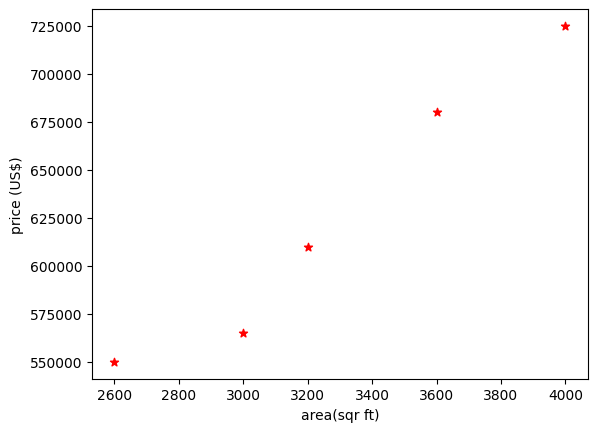

In [20]:
plt.xlabel('area(sqr ft)')
plt.ylabel('price (US$)')
plt.scatter(df.areas,df.prices,color='red',marker="*")

In [27]:
reg=linear_model.LinearRegression()

## make a list of the independent values and call this variable X.

## Put the dependent values in a variable called y.

## It is common to name the list of independent values with a upper case X, and the list of dependent values with a lower case y.

In [28]:
X=df[["areas"]]
y=df["prices"]

In [30]:
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
predictedValue=reg.predict([[3300]])
print(predictedValue)

[628715.75342466]


/Users/kristalshrestha/Code/LLM_Scratch/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
import sys
print(sys.version)
print(sys.prefix)

3.10.18 (main, Jun  3 2025, 18:23:41) [Clang 17.0.0 (clang-1700.0.13.3)]
/Users/kristalshrestha/Code/LLM_Scratch/venv


In [ ]:
print(reg.coef_) # slope

[135.78767123]


In [36]:
print(reg.intercept_) #intercept

180616.43835616432


## so our eqn is y=mx + b 
## y = 135.78767123*X + 180616.43835616432



In [37]:
135.78767123*3300 + 180616.43835616432

628715.7534151643

## Now lets visualize how the linear regression line looks like

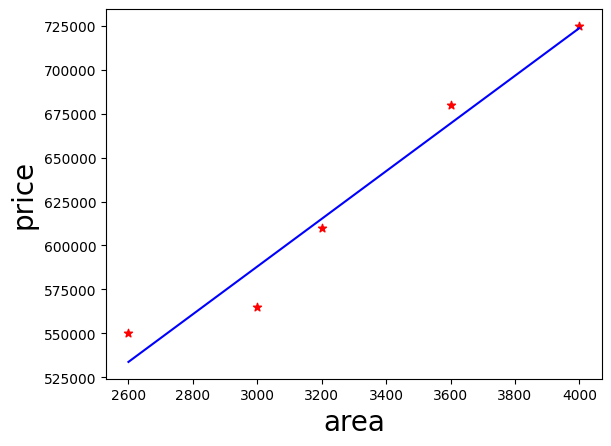

In [57]:
plt.xlabel("area",fontsize=20)
plt.ylabel("price",fontsize=20)
plt.scatter(X,y,color="red",marker="*")
plt.plot(X,reg.predict(X),color="blue")

In [40]:
predictedValue2=reg.predict([[5000]])
print(predictedValue2)

[859554.79452055]


/Users/kristalshrestha/Code/LLM_Scratch/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Now using this model i will predict all the values i have to predict in 1 go

In [41]:
df2=pd.read_csv('areas.csv')

In [42]:
df2

,area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,3460
8,4750
9,2300


In [44]:
reg.predict(df2)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- area
Feature names seen at fit time, yet now missing:
- areas


## When you trained the model (reg.fit), your input dataframe column was named areas.

## Now when you do reg.predict(df2), your df2 has a column named area (singular).

## The column name must match exactly between training and prediction data.

In [45]:
df2 = df2.rename(columns={"area": "areas"})


In [46]:
reg.predict(df2)

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466,  650441.78082192,  825607.87671233,
        492928.08219178, 1402705.47945205, 1348390.4109589 ,
       1144708.90410959])

In [47]:
predictedValues=reg.predict(df2)

In [49]:
df2["prices"]=predictedValues

In [50]:
df2

,areas,prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [52]:
df2.to_csv("Output.csv")

In [53]:
df2.to_csv("Output1.csv",index=False)